In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()

In [4]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = { s:i+1 for i,s in enumerate(chars) }
stoi['.'] = 0
itos = { i:s for s,i in stoi.items() }
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [52]:
block_size = 3
X, Y = [], []

for w in words:
        # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [8]:
C = torch.randn((27, 2))

In [11]:
emb = C[X]
emb

tensor([[[ 0.9522,  0.8745],
         [ 0.9522,  0.8745],
         [ 0.9522,  0.8745]],

        [[ 0.9522,  0.8745],
         [ 0.9522,  0.8745],
         [-1.1372,  0.0587]],

        [[ 0.9522,  0.8745],
         [-1.1372,  0.0587],
         [-1.1705, -0.9295]],

        [[-1.1372,  0.0587],
         [-1.1705, -0.9295],
         [-1.1705, -0.9295]],

        [[-1.1705, -0.9295],
         [-1.1705, -0.9295],
         [ 0.1960, -0.0948]],

        [[ 0.9522,  0.8745],
         [ 0.9522,  0.8745],
         [ 0.9522,  0.8745]],

        [[ 0.9522,  0.8745],
         [ 0.9522,  0.8745],
         [ 0.0712, -0.1576]],

        [[ 0.9522,  0.8745],
         [ 0.0712, -0.1576],
         [-0.1236,  0.5459]],

        [[ 0.0712, -0.1576],
         [-0.1236,  0.5459],
         [-1.6905, -0.7144]],

        [[-0.1236,  0.5459],
         [-1.6905, -0.7144],
         [ 1.1159, -0.4075]],

        [[-1.6905, -0.7144],
         [ 1.1159, -0.4075],
         [-1.6905, -0.7144]],

        [[ 1.1159, -0

In [18]:
W1 = torch.randn((6, 100))
b1  = torch.randn((100))

In [19]:
h = torch.tanh(emb.view(-1, 6) @ W1 + B1)
h

tensor([[ 0.9934, -0.9918, -0.2456,  ..., -0.9759,  0.9902, -0.1435],
        [-0.5931,  0.8919,  0.9844,  ..., -0.2197,  0.7743,  0.2623],
        [-0.9737,  0.9998,  0.9993,  ..., -0.8989, -0.9854,  0.9786],
        ...,
        [ 0.9999, -0.9999, -0.1094,  ..., -0.8821,  0.5269, -0.6540],
        [-0.9999,  0.9903,  0.9120,  ...,  0.9953,  0.8941,  0.9657],
        [ 0.9690,  0.9788,  0.9952,  ..., -0.9992, -0.9949,  0.7239]])

In [20]:
h.shape

torch.Size([32, 100])

In [21]:
W2 = torch.randn((100, 27))
b2 = torch.randn((27))

In [26]:
logits = h @ W2 + b2
counts = logits.exp()
counts

tensor([[2.3532e-06, 2.0127e-03, 1.1397e+06, 1.9997e-04, 1.3293e+04, 1.3999e+04,
         2.8911e+02, 2.5449e-02, 7.8233e-02, 3.0664e-01, 4.5891e-03, 2.7173e-08,
         7.4173e+02, 1.3193e+04, 7.0171e-01, 1.1600e-01, 1.9644e-09, 6.2975e+05,
         5.2231e-02, 3.8359e-02, 4.9870e+01, 5.2687e+01, 9.4982e-04, 2.3622e+02,
         3.0473e+01, 3.6541e+02, 5.1145e-05],
        [1.8298e-04, 2.2441e-04, 6.9074e+00, 5.2863e-07, 9.8842e-07, 3.8615e+01,
         3.5697e-01, 2.0992e-03, 2.7812e+04, 4.0907e+04, 5.0071e-03, 6.2589e+01,
         3.1473e+07, 5.6274e-01, 3.3421e-05, 2.3502e-04, 3.9597e+01, 1.3874e-04,
         1.9051e-02, 6.0550e+03, 6.5417e+02, 2.4509e+03, 2.4085e-04, 1.7238e-04,
         5.8453e+03, 2.1196e-03, 7.0657e-01],
        [3.5937e-02, 9.6044e-04, 5.3439e+02, 1.2475e+00, 2.1413e-02, 4.1682e-08,
         1.3920e+05, 2.4716e+00, 6.7983e-01, 7.0729e-01, 8.7401e-01, 1.1556e+00,
         1.7935e+05, 4.1228e-05, 1.7524e-04, 1.7686e-06, 1.3449e+04, 6.0461e-08,
         2.6345e+

In [33]:
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(16.8581)

In [109]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn((100), generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn((27))
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

3481


In [106]:
ix = torch.randint(0, X.shape[0], (32,))
emb = C[X[ix]]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(32), Y[ix]].log().mean()
print(loss)
loss = F.cross_entropy(logits, Y[ix])
print(loss)

tensor(2.9266, grad_fn=<NegBackward0>)
tensor(2.9266, grad_fn=<NllLossBackward0>)


In [110]:
for p in parameters:
    p.requires_grad = True

In [111]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre
print(lrs)

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [115]:
lri = []
lossi = []
for i in range(1000):
    ix = torch.randint(0, X.shape[0], (32,))
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    for p in parameters:
        p.grad = None
    loss.backward()
    print(f'{loss=}')

    lr = 10 ** (-1.5)
    for p in parameters:
        p.data += -lr * p.grad
    # lri.append(lre[i].item())
    # lossi.append(loss.item())

loss=tensor(2.4255, grad_fn=<NllLossBackward0>)
loss=tensor(2.2474, grad_fn=<NllLossBackward0>)
loss=tensor(2.4903, grad_fn=<NllLossBackward0>)
loss=tensor(2.4630, grad_fn=<NllLossBackward0>)
loss=tensor(2.7238, grad_fn=<NllLossBackward0>)
loss=tensor(2.5172, grad_fn=<NllLossBackward0>)
loss=tensor(2.3526, grad_fn=<NllLossBackward0>)
loss=tensor(2.3120, grad_fn=<NllLossBackward0>)
loss=tensor(2.4812, grad_fn=<NllLossBackward0>)
loss=tensor(2.4251, grad_fn=<NllLossBackward0>)
loss=tensor(2.5746, grad_fn=<NllLossBackward0>)
loss=tensor(2.2097, grad_fn=<NllLossBackward0>)
loss=tensor(2.3382, grad_fn=<NllLossBackward0>)
loss=tensor(2.5078, grad_fn=<NllLossBackward0>)
loss=tensor(2.2356, grad_fn=<NllLossBackward0>)
loss=tensor(2.5832, grad_fn=<NllLossBackward0>)
loss=tensor(2.2474, grad_fn=<NllLossBackward0>)
loss=tensor(2.5190, grad_fn=<NllLossBackward0>)
loss=tensor(2.7445, grad_fn=<NllLossBackward0>)
loss=tensor(2.4362, grad_fn=<NllLossBackward0>)
loss=tensor(2.2652, grad_fn=<NllLossBack

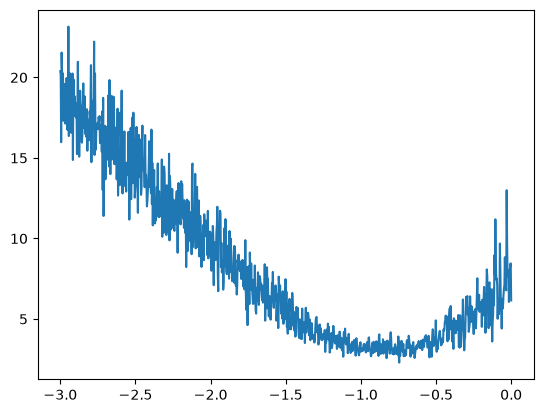

In [97]:
plt.plot(lri, lossi)

In [58]:
torch.randint(0, X.shape[0], (32,))

tensor([ 68741, 222567,   2282,  53948, 174890,  74278, 226879, 183616, 122242,
         44478, 180874, 227319,  64038, 140586,  40061,  22905, 200460, 100023,
          1518, 101381, 171046,  21757, 143091,  68687,  20567, 166861, 112078,
         40439, 218281,  66551, 104810, 213514])